In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")

y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

In [3]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (125973, 122)
X_test : (22544, 122)
y_train: (125973,)
y_test : (22544,)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [5]:
print("Before scaling:")
print(X_train.iloc[:, :5].describe())

Before scaling:
       cat__protocol_type_icmp  cat__protocol_type_tcp  \
count            125973.000000           125973.000000   
mean                  0.065816                0.815167   
std                   0.247961                0.388164   
min                   0.000000                0.000000   
25%                   0.000000                1.000000   
50%                   0.000000                1.000000   
75%                   0.000000                1.000000   
max                   1.000000                1.000000   

       cat__protocol_type_udp  cat__service_IRC  cat__service_X11  
count           125973.000000     125973.000000     125973.000000  
mean                 0.119018          0.001484          0.000579  
std                  0.323810          0.038500          0.024066  
min                  0.000000          0.000000          0.000000  
25%                  0.000000          0.000000          0.000000  
50%                  0.000000          0.000000      

In [6]:
print("\nAfter scaling:")
print(pd.DataFrame(X_train_scaled).iloc[:, :5].describe())


After scaling:
                  0             1             2             3             4
count  1.259730e+05  1.259730e+05  1.259730e+05  1.259730e+05  1.259730e+05
mean   2.450770e-17 -7.755600e-17 -1.720333e-18 -6.430098e-18 -1.466514e-17
std    1.000004e+00  1.000004e+00  1.000004e+00  1.000004e+00  1.000004e+00
min   -2.654290e-01 -2.100067e+00 -3.675546e-01 -3.855713e-02 -2.407956e-02
25%   -2.654290e-01  4.761753e-01 -3.675546e-01 -3.855713e-02 -2.407956e-02
50%   -2.654290e-01  4.761753e-01 -3.675546e-01 -3.855713e-02 -2.407956e-02
75%   -2.654290e-01  4.761753e-01 -3.675546e-01 -3.855713e-02 -2.407956e-02
max    3.767485e+00  4.761753e-01  2.720684e+00  2.593554e+01  4.152900e+01


In [7]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    # Training
    start_train = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start_train

    # Prediction
    start_predict = time.time()
    
    y_pred = model.predict(X_test)
    
    predict_time = time.time() - start_predict

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1 = report["1"]["f1-score"]

    # Results
    print("=" * 50)
    print(f"Model: {model.__class__.__name__}")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print(f"Training Time   : {train_time:.4f} seconds")
    print(f"Prediction Time : {predict_time:.4f} seconds")

    print("\nClassification Report:")
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Normal", "Attack"]
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Attack"]
    )

    disp.plot()
    plt.show()

    return {
        "model": model.__class__.__name__,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "train_time": train_time,
        "predict_time": predict_time
    }

In [8]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

Model: KNeighborsClassifier
Accuracy : 0.7704
Precision: 0.9234
Recall   : 0.6507
F1-Score : 0.7635
Training Time   : 0.0442 seconds
Prediction Time : 26.9835 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.67      0.93      0.78      9711
      Attack       0.92      0.65      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.80      0.79      0.77     22544
weighted avg       0.81      0.77      0.77     22544



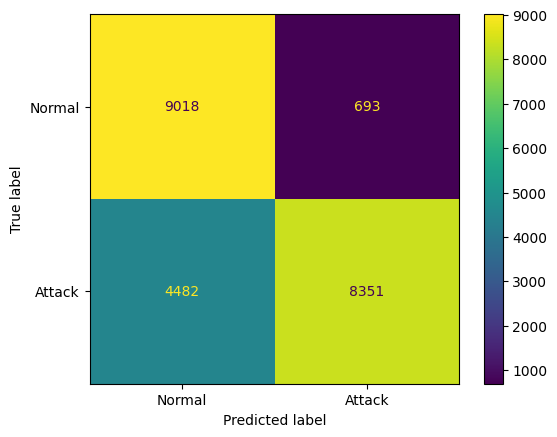

In [9]:
knn_result = evaluate_model(
    knn,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)